In [1]:
import random
import introns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
genome_mixed, genes_mixed = introns.HELP_load_default_genome_genes(if_classifier_mixed=True)
mixed_introns_set = [i for (_, gene) in genes_mixed.items() for i in gene.introns]

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 495.09it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


In [3]:
genome_ml, genes_ml = introns.HELP_load_default_genome_genes(if_classifier_mixed=False)
ml_introns_set = [i for (_, gene) in genes_ml.items() for i in gene.introns]

Creating genes, sequences, introns, exons and introns' class prediction


100%|██████████| 117/117 [00:00<00:00, 547.35it/s]


[CREATE] Genes, sequences, introns, exons created, introns' classes predicted
predict_all_introns checkpoint 1/4
predict_all_introns checkpoint 2/4
predict_all_introns checkpoint 3/4
predict_all_introns checkpoint 4/4


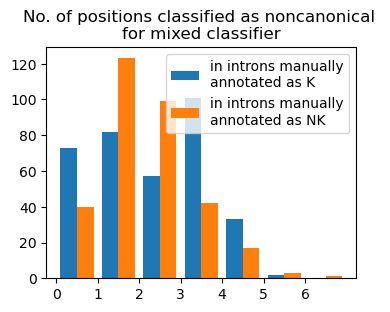

In [4]:
introns.plot_man_annotation_positions_counts(mixed_introns_set, title_add="\nfor mixed classifier")

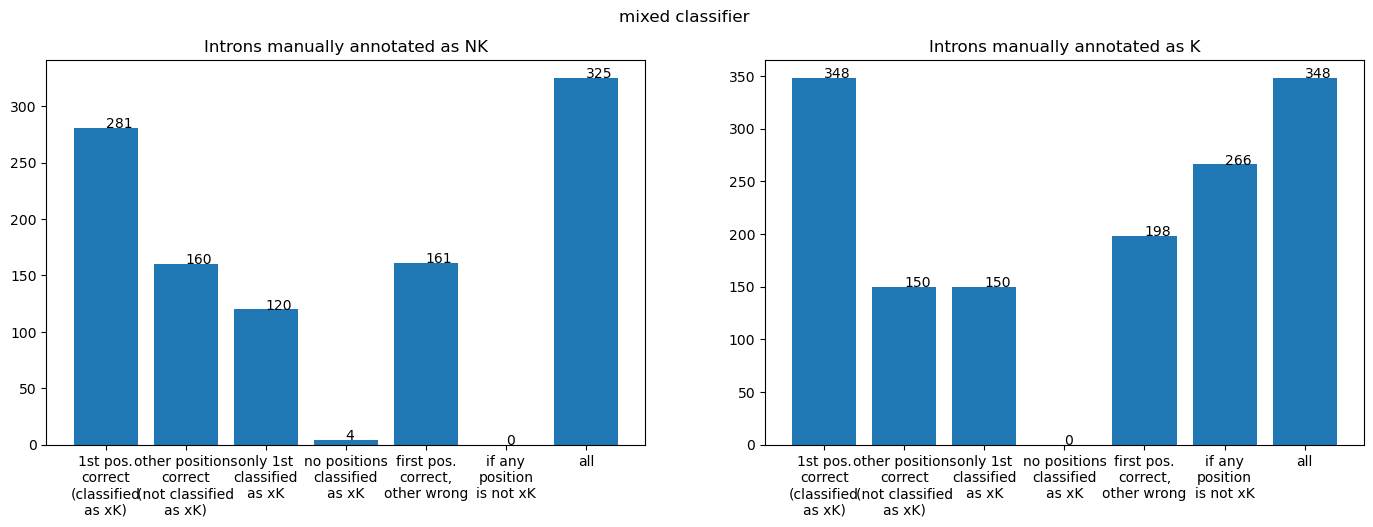

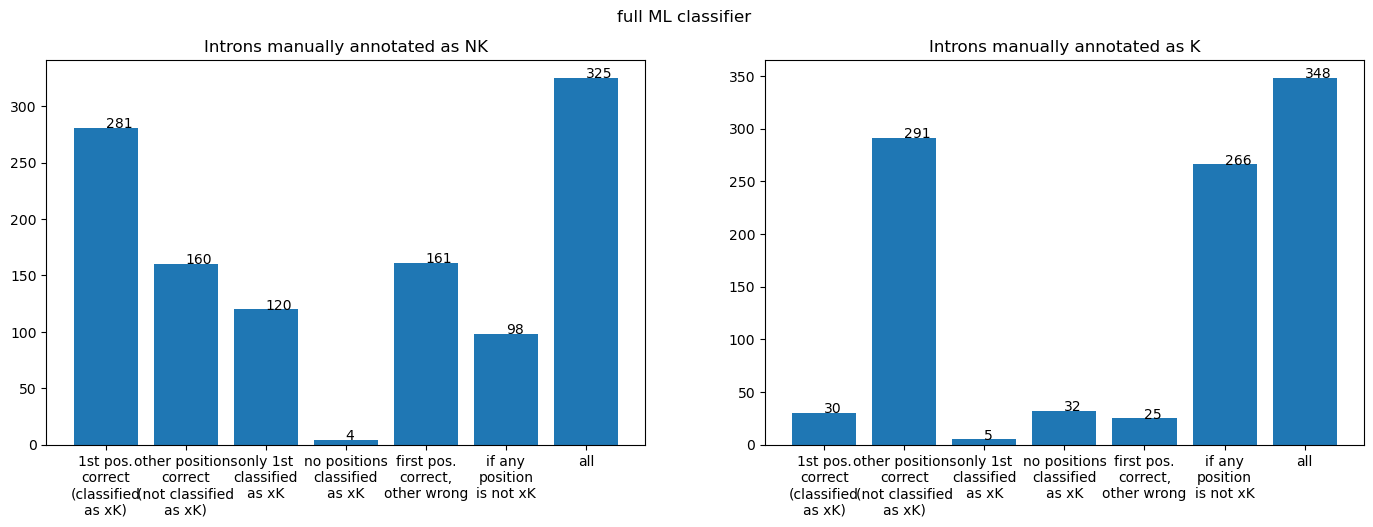

In [5]:
introns.plot_correct_positions(mixed_introns_set, title="mixed classifier")
introns.plot_correct_positions(ml_introns_set, title="full ML classifier")

In [7]:
random.shuffle(mixed_introns_set)
halfway = int(len(mixed_introns_set)/2)
introns_clf_set, introns_validation_set = mixed_introns_set[:halfway], mixed_introns_set[halfway:]

In [8]:
train_test_set, true_classes = [], []

for intron in introns_clf_set:
    for i in intron.variants+[intron]:
        i.ML_characteristic = introns.compute_intron_characteristics(i, whether_weighted_scores=True)
        train_test_set.append(i.ML_characteristic)
        if i.man_annotation == "intron_NK":
            true_classes.append(1)
        else:
            true_classes.append(0)
                
print(train_test_set[0])
print(true_classes[0])

[1.    0.    0.    0.    0.    1.    3.625 2.   ]
0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(train_test_set, true_classes, random_state=2137, shuffle=True)

In [10]:
clf_nk = xgb.XGBClassifier(eval_metric='aucpr')
clf_nk.fit(X_train, y_train);

In [11]:
y_predicted = clf_nk.predict(X_test)
print(classification_report(y_test, y_predicted))
print(confusion_matrix(y_test, y_predicted), "\n\n")

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       237
           1       0.55      0.50      0.52        36

    accuracy                           0.88       273
   macro avg       0.74      0.72      0.73       273
weighted avg       0.87      0.88      0.88       273

[[222  15]
 [ 18  18]] 




2. Polaczenie klasyfikatorow

In [12]:
for intron in introns_validation_set:
    for i in intron.variants+[intron]:
        is_k = int(bool(i.is_conventional))
        
        i.ML_characteristic = introns.compute_intron_characteristics(i, whether_weighted_scores=True).reshape(1, -1)
        is_nk = clf_nk.predict(i.ML_characteristic)[0]
        
        i.ML_class = [is_k, is_nk]

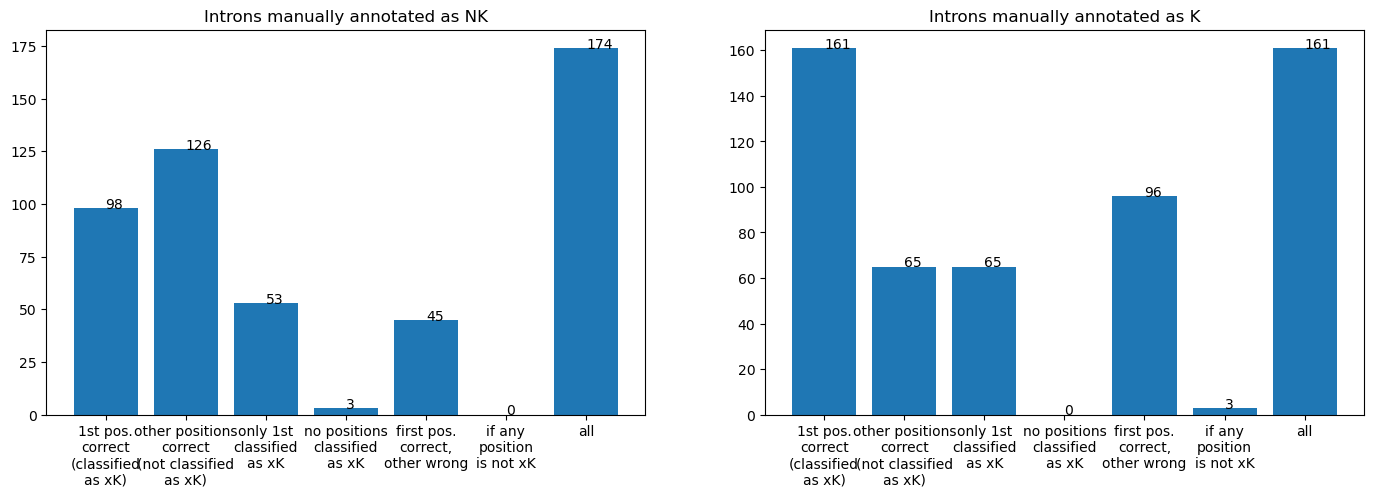

In [13]:
introns.plot_correct_positions(introns_validation_set)

## Plot of how many introns have positions classified as what

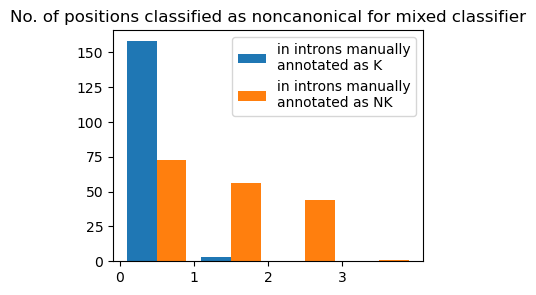

In [14]:
introns.plot_man_annotation_positions_counts(introns_validation_set, title_add="for mixed classifier")